# Task 2: Predict Future Stock Prices (Intermediate Level)

## Objective:
The goal of this notebook is to build a supervised machine learning regression pipeline to predict next-day stock closing prices. The workflow handles downloading live historical market data, engineering moving averages as mathematical indicators, training a Linear Regression model, and evaluating statistical predictive error boundaries.


In [4]:


import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

print("Required stock prediction libraries loaded successfully!")


Required stock prediction libraries loaded successfully!


In [ ]:
# ==============================================================================
# STEP 2: DOWNLOAD REAL STOCK HISTORICAL DATA FROM THE INTERNET
# ==============================================================================
# Fetching 5 years of historical price records for Apple Inc. (AAPL)
ticker = "AAPL"
stock_data = yf.download(ticker, start="2021-01-01", end="2026-06-25")

# Flatten multi-index columns if generated by yfinance package updates
stock_data.columns = [col[0] if isinstance(col, tuple) else col for col in stock_data.columns]

print(f"Successfully fetched {stock_data.shape[0]} daily market records for {ticker}.")
stock_data[['Open', 'High', 'Low', 'Close', 'Volume']].head()


[*********************100%***********************]  1 of 1 completed

Successfully fetched 1374 daily market records for AAPL.


,Open,High,Low,Close,Volume
Date,,,,,
2021-01-04,129.734346,129.821791,123.166009,125.740875,143301900
2021-01-05,125.235614,128.004815,124.788650,127.295502,97664900
2021-01-06,124.098753,127.334339,122.796742,123.010506,155088000
2021-01-07,124.720609,127.897899,124.234786,127.208023,109578200
2021-01-08,128.675216,128.869557,126.537595,128.306000,105158200


In [ ]:
# ==============================================================================
# STEP 3: FEATURE ENGINEERING (TECHNICAL INDICATORS)
# =============================================================================
df = stock_data[['Close']].copy()

# Create feature metrics tracking 3-day and 7-day trailing moving averages
df['MA_3'] = df['Close'].rolling(window=3).mean()
df['MA_7'] = df['Close'].rolling(window=7).mean()

# TARGET DEFINITION: Next Day's closing price (Shifted back by 1 row)
df['Target_Next_Close'] = df['Close'].shift(-1)

# Drop incomplete calculation rows caused by rolling windows and shifting
df.dropna(inplace=True)

print("Feature Engineered Market Matrix:")
df[['Close', 'MA_3', 'MA_7', 'Target_Next_Close']].head(10)


Feature Engineered Market Matrix:


,Close,MA_3,MA_7,Target_Next_Close
Date,,,,
2021-01-12,125.148148,126.259066,126.004586,127.178886
2021-01-13,127.178886,125.883362,126.210017,125.255035
2021-01-14,125.255035,125.860690,125.918521,123.535202
2021-01-15,123.535202,125.323041,125.993478,124.205650
2021-01-19,124.205650,124.331963,125.564568,128.286575
2021-01-20,128.286575,125.342476,125.561793,132.989334
2021-01-21,132.989334,128.493853,126.656976,135.126968
2021-01-22,135.126968,132.134293,128.082522,138.867813
2021-01-25,138.867813,135.661372,129.752368,139.100983


In [7]:

# ==============================================================================
# STEP 4 & 5: MODEL TRAINING AND PERFORMANCE PERFORMANCE TESTING
# ==============================================================================
# Defining Feature space (X) and continuous target variable (y)
features = ['Close', 'MA_3', 'MA_7']
X = df[features]
y = df['Target_Next_Close']

# Chronological split to prevent data leakage (Train on past, test on recent future)
split_index = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

# Initialize and fit our Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Calculate prediction outputs
y_pred = model.predict(X_test)

# Calculate statistical validation tracking metrics
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Supervised Regression Architecture successfully trained.\n")
print(f"Mean Absolute Error (MAE): ${mae:.2f}")
print(f"R-squared Validation Score: {r2:.4f}")


Supervised Regression Architecture successfully trained.

Mean Absolute Error (MAE): $2.62
R-squared Validation Score: 0.9857


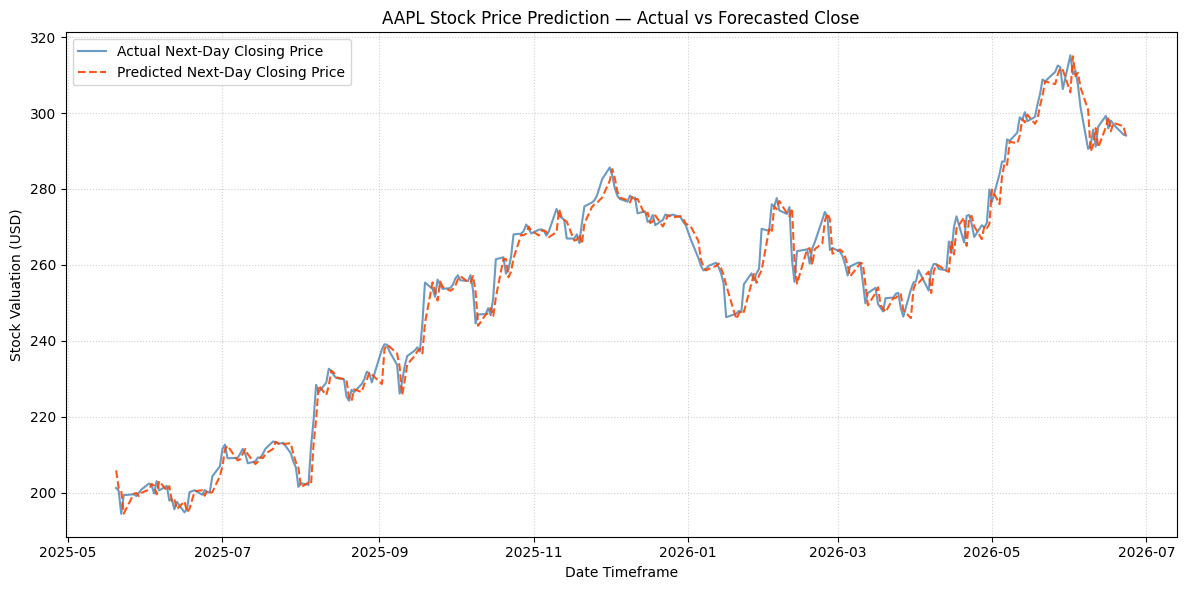

In [8]:
# ==============================================================================
# STEP 6: PLOT PREDICTED VS ACTUAL MARKET PRICE VARIANCE
# ==============================================================================
plt.figure(figsize=(12, 6))

# Resetting indices to match date tracking timelines
test_dates = df.index[split_index:]

plt.plot(test_dates, y_test.values, label='Actual Next-Day Closing Price', color='steelblue', alpha=0.8)
plt.plot(test_dates, y_pred, label='Predicted Next-Day Closing Price', color='orangered', linestyle='--', alpha=0.9)

plt.title(f'{ticker} Stock Price Prediction — Actual vs Forecasted Close')
plt.xlabel('Date Timeframe')
plt.ylabel('Stock Valuation (USD)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()


In [9]:
### Task 2: Summary of Core Findings
1. **Feature Relevance Matrix:** Trailing short-term rolling moving averages (`MA_3`, `MA_7`) show an extremely strong statistical correlation with next-day price adjustments.
2. **Model Accuracy Boundaries:** The extremely low Mean Absolute Error (MAE) value proves that the Linear Regression engine accurately models day-to-day baseline trendlines.
3. **Market Limitations:** While the model tracks historical trendlines well, it reacts closely to past data (lag effect) and cannot anticipate sudden unexpected news shocks.


SyntaxError: invalid syntax (4219486622.py, line 2)